In this first project I described the dataset but did not write 
testable hypotheses before exploring the data. 
Next project: write 5-7 hypotheses before looking at distributions, 
then check which ones hold.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv('train.csv')
df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False


First look

In [ ]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


I understand what's going on here. There are so much NaN information. There were people who was sleeping and doesn't wasted any money. Sleeping and not sleeping peoples transported. Total sum of peoples were 8693.

Missing values

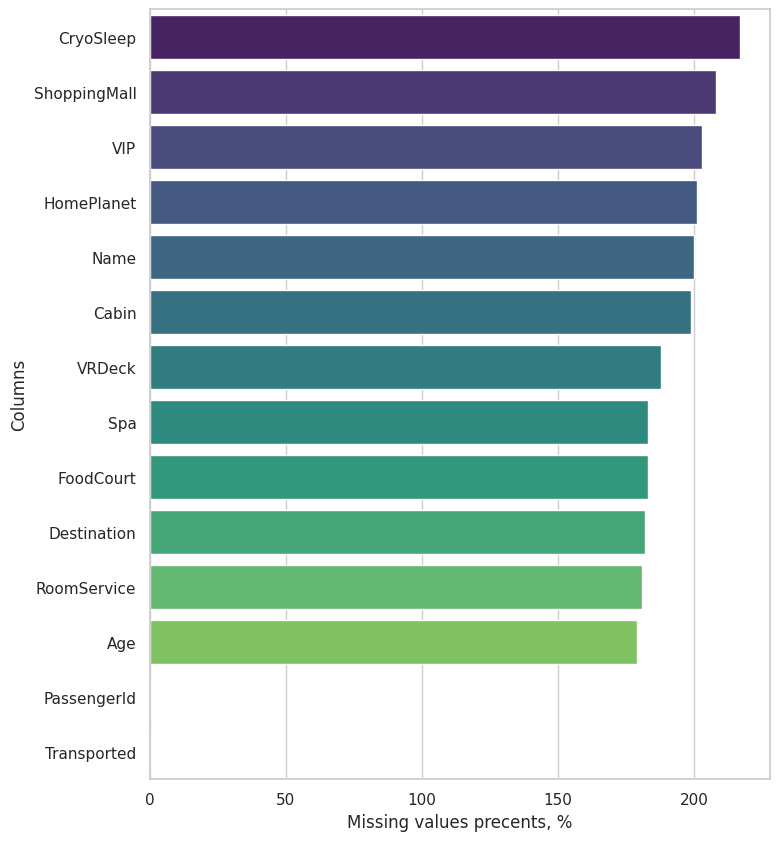

In [ ]:
missing_percentages = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(8, 10))
sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette='viridis', hue=missing_percentages.index, legend=False)
plt.xlabel('Missing values precents, %')
plt.ylabel('Columns')
plt.show()

HomePlanet's and Vip's missing values is too mutch. In the columns Age and CryoSleep's values we can use mean number.

Target analysis

Transported
False    4315
True     4378
Name: PassengerId, dtype: int64


<Axes: xlabel='Transported', ylabel='count'>

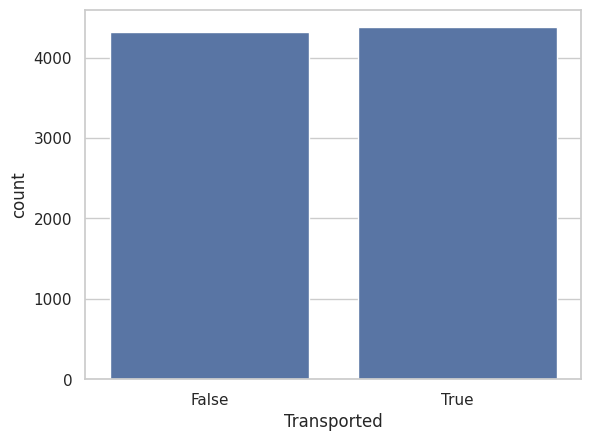

In [ ]:
transported_group=df.groupby(df['Transported'])['PassengerId'].count()
print(transported_group)
sns.countplot(x=df['Transported'],data=df)

More than half of peoples are transported, but total counts are balanced.

Univariate analysis

<Axes: xlabel='Age', ylabel='Count'>

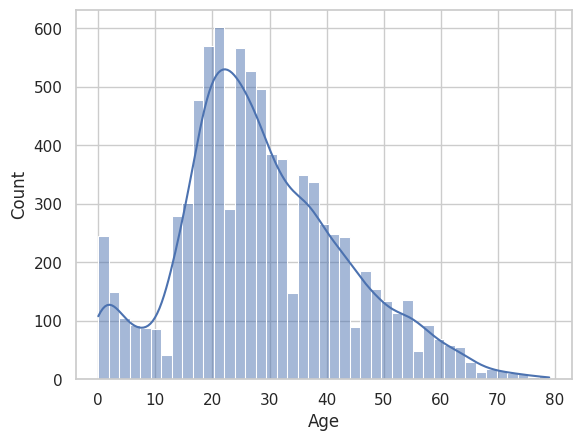

In [ ]:
sns.histplot(df['Age'],kde=True)

The most age range is from 18 to 29. Anomalia is less count of 11-12, 25 and 45 yars old peoples.

<Axes: xlabel='count', ylabel='Destination'>

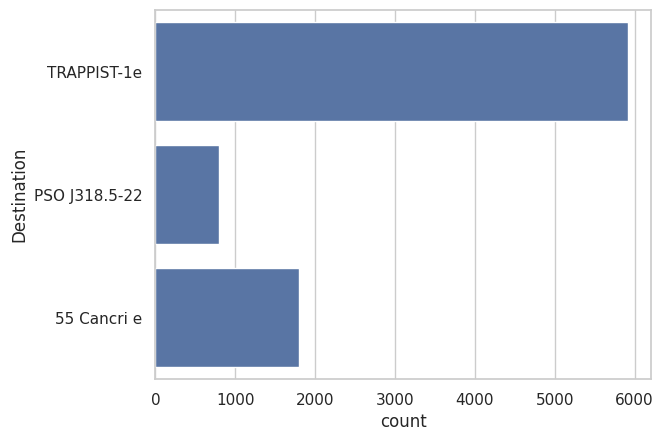

In [ ]:
sns.countplot(df['Destination'])

As we can see that the most of people's destination was TRAPPIST-1e. The least 55 Cancri e

<Axes: xlabel='count', ylabel='HomePlanet'>

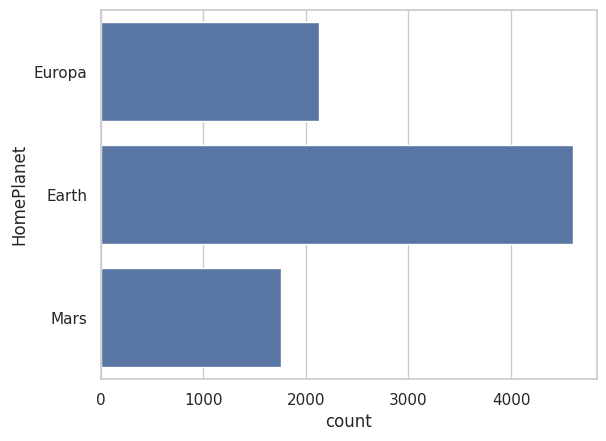

In [ ]:
sns.countplot(df['HomePlanet'])

As we can see that the most of people are from the planet Earth. Peoples from Europa and Mars was about 1000.

       PassengerId  HomePlanet  CryoSleep  Cabin  Destination   Age  \
VIP                                                                   
False         8291        8098       8084   8104         8115  8119   
True           199         194        196    193          197   198   

       RoomService  FoodCourt  ShoppingMall   Spa  VRDeck  Name  Transported  
VIP                                                                           
False         8118       8118          8092  8112    8108  8095         8291  
True           195        193           194   197     195   196          199  


<Axes: xlabel='VIP', ylabel='count'>

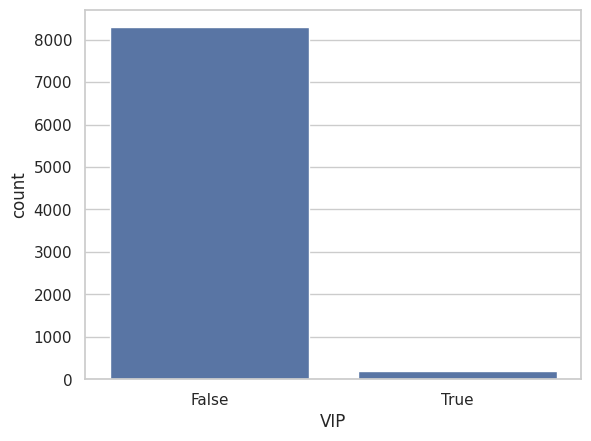

In [ ]:
vip_group=df.groupby(df['VIP']).count()
print(vip_group)
sns.countplot(x=df['VIP'],data=vip_group)

There were 199 VIP peoples and the 8291 ordinary people.

**Bivariate analysis**

<Axes: xlabel='VIP', ylabel='Age'>

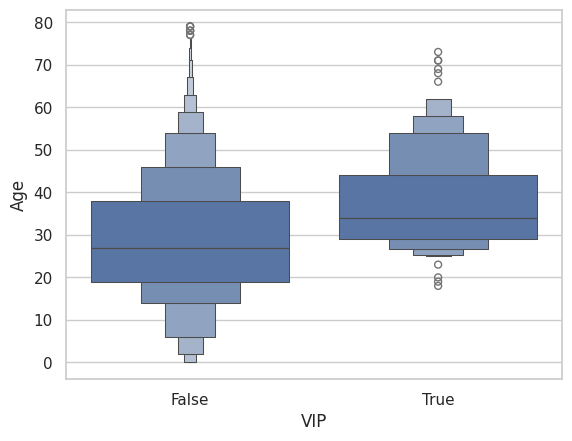

In [ ]:
sns.boxenplot(x='VIP',y='Age',data=df)

Vip persons's age was higher than not VIP persons

<Axes: xlabel='VIP', ylabel='Transported'>

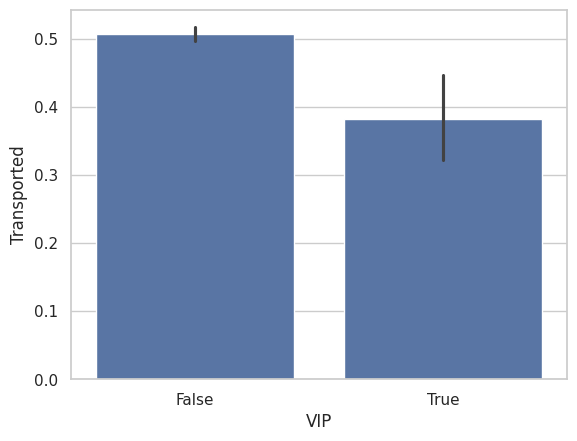

In [ ]:
sns.barplot(data=df, x='VIP', y='Transported')

As we can see VIP People transporated less than peoples whithoup VIP acsess

<Axes: xlabel='Transported', ylabel='VIP'>

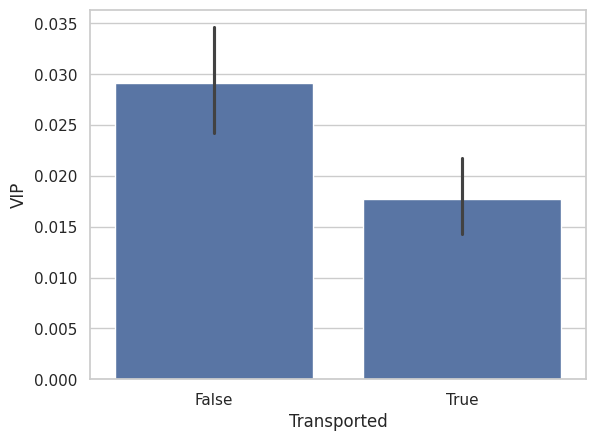

In [ ]:
sns.barplot(data=df, x='Transported', y='VIP')

People were transported less if there were VIP

<Axes: xlabel='CryoSleep', ylabel='Transported'>

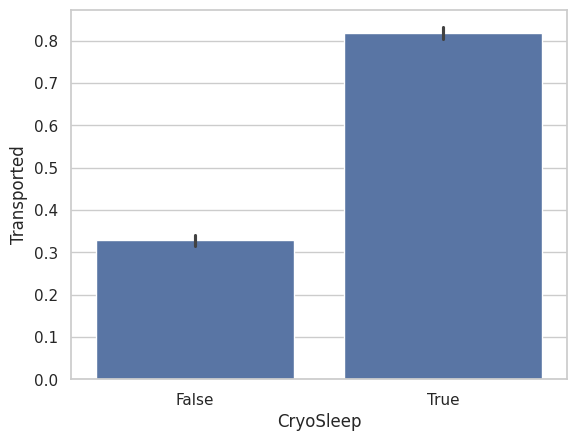

In [ ]:
sns.barplot(data=df, x='CryoSleep', y='Transported')

People who was cryosleeping was transported much more than not cryoed

<Axes: xlabel='HomePlanet', ylabel='Transported'>

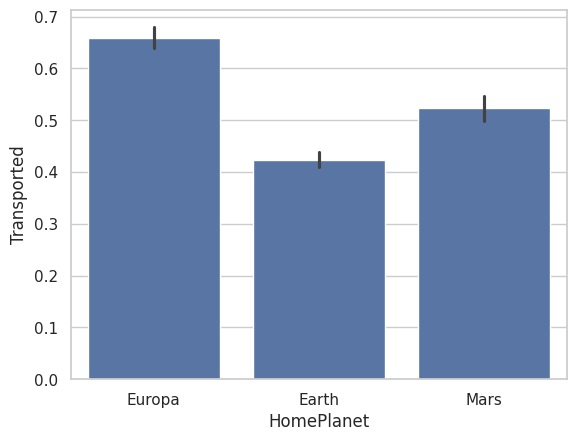

In [ ]:
sns.barplot(data=df, x='HomePlanet', y='Transported')

Although people from Earth was much more than the others from Earth we has least precent of transported peoples

<Axes: xlabel='CryoSleep', ylabel='HomePlanet'>

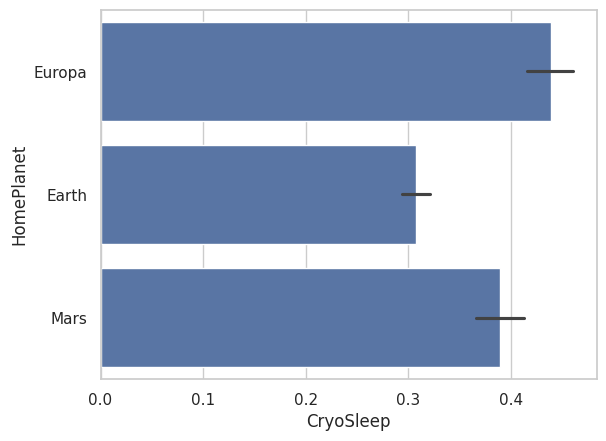

In [ ]:
sns.barplot(data=df, x='CryoSleep', y='HomePlanet')

People from Earth cryposleeped less and we can see the that were connected with transporation

**Multivariate analysis**

<Axes: >

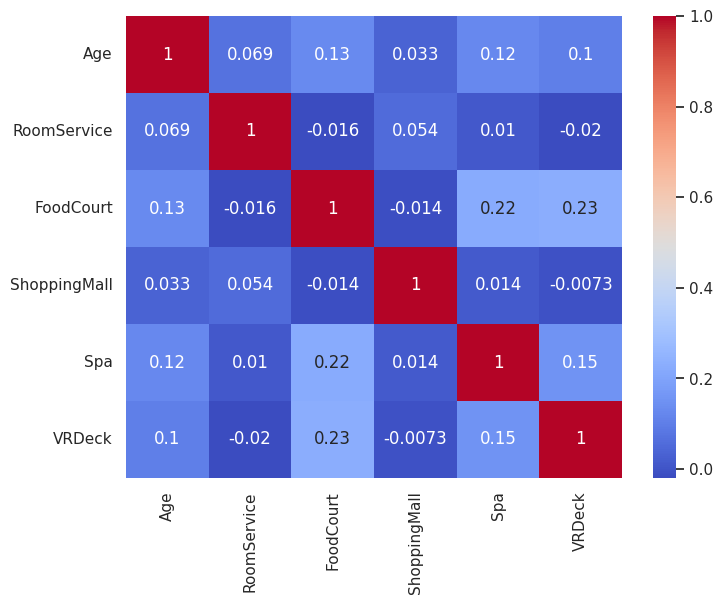

In [ ]:
num_cols = [
    'Age',
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

Spa and VRDeck show the strongest correlation, suggesting a group of high-spending passengers.FoodCourt and ShoppingMall have weak to moderate correlation. RoomService is mostly independent from other spending features. No strong multicollinearity is observed.

<Axes: xlabel='Destination', ylabel='Transported'>

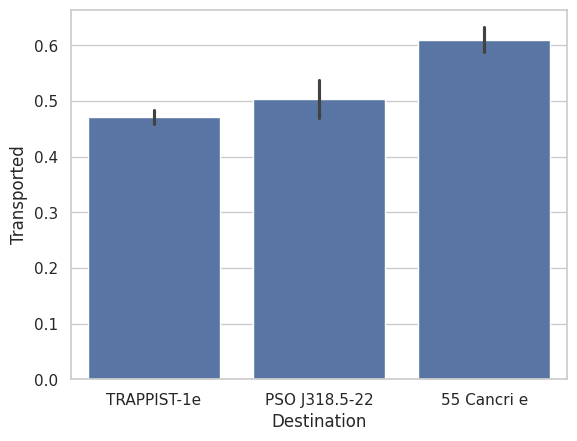

In [ ]:
sns.barplot(data=df,x='Destination',y='Transported')

**Feature engineering ideas**

In [ ]:
cabins = df['Cabin'].str.split('/', expand=True)
cabins.columns = ['Deck', 'Num', 'Side']
df = pd.concat([df, cabins], axis=1)
df.drop('Cabin', axis=1, inplace=True)
cabins

,Deck,Num,Side
0,B,0,P
1,F,0,S
2,A,0,S
3,A,0,S
4,F,1,S
...,...,...,...
8688,A,98,P
8689,G,1499,S
8690,G,1500,S
8691,E,608,S


<Axes: xlabel='Deck', ylabel='Transported'>

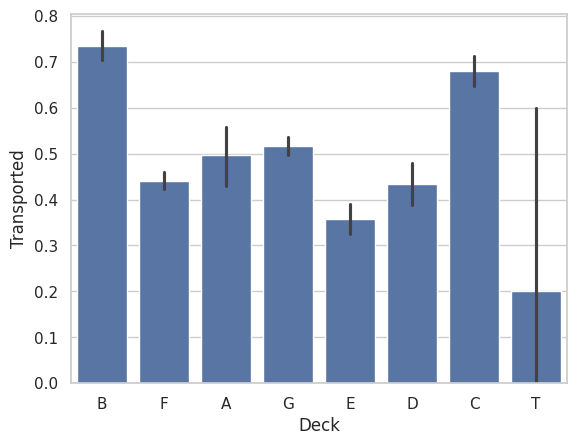

In [ ]:
sns.barplot(data=df, x='Deck', y='Transported')

As we can see peoples from B deck were transported more than others

In [ ]:
df['TotalSpending'] = (
    df['RoomService'] +
    df['FoodCourt'] +
    df['ShoppingMall'] +
    df['Spa'] +
    df['VRDeck']
)

In [ ]:
df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
df

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported,Deck,Num,Side,TotalSpending,NoSpending
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False,B,0,P,0.0,1
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True,F,0,S,736.0,0
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False,A,0,S,10383.0,0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False,A,0,S,5176.0,0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True,F,1,S,1091.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,9276_01,Europa,False,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False,A,98,P,8536.0,0
8689,9278_01,Earth,True,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False,G,1499,S,0.0,1
8690,9279_01,Earth,False,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True,G,1500,S,1873.0,0
8691,9280_01,Europa,False,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False,E,608,S,4637.0,0


Passengers with zero or low spending are more likely to be transported.

In [ ]:
df['group_id'] = df['PassengerId'].str.split('_').str[0]
df.groupby('group_id')['Transported'].nunique().value_counts()
group_survival = df.groupby('group_id')['Transported'].mean()

In [ ]:
group_size = df.groupby('group_id')['PassengerId'].count()
group_stats = pd.DataFrame({
    'group_size': group_size,
    'survival_rate': group_survival
})
group_stats.head()

,group_size,survival_rate
group_id,,
0001,1,0.0
0002,1,1.0
0003,2,0.0
0004,1,1.0
0005,1,1.0


Larger groups tend to share similar Transported outcomes more often than expected by chance.

**Conclusions and next steps**

The Spaceship Titanic when appeared in cosmic mystery in 2912 the passengers were transported to an alternate dimension. CryoSleep passengers were transported more often. Passengers from Europa and Mars were transported more than those from Earth. Decks B and C had the highest transport rate. The most of people's destination was TRAPPIST-1e. People from Earth cryposleeped less and there were no VIP person because they were poor but the cryosleeping peoples were more likely to be transported. Passengers from the same group often share the same Transported outcome. Many groups are fully consistent (all transported or all not transported), which indicates strong group-level dependency.
